In [3]:
fig_num = 5 # change this to the figure number
analysis_name = "mpfc_task_progression" # change this to the subfolder it should save to

In [9]:
%load_ext autoreload
%autoreload 2

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "9"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

# Define Data Files/Paths
subject = "wilbur"
date = "20210406"
file_name = subject + date
nwb_file_name = file_name + "_.nwb"

from spyglass.decoding.v1.c3po import Model
import matplotlib.pyplot as plt

if date == "20210404":
    marks_group_name = "mpfc1"
else:
    marks_group_name = "mpfc"

marks_group_name = "mpfc_HYBRID"

model_key = {
    "nwb_file_name": nwb_file_name,
    "marks_group_name": marks_group_name,
    "model_name":"wilbur_v0_HYBRID_20210406_128d"
    # "training_params_name":"wilbur_post_fix"
}
Model & model_key
model_key = (Model() & model_key).fetch1("KEY")
if "128d" in model_key["model_name"]:
    checkpoint = None
else:
    checkpoint = 6

analysis = (Model() & model_key).fetch_c3po_analysis(model_key, checkpoint=checkpoint)


from c3po.analysis.analysis import figure_directory
from pathlib import Path
first_epochs = False
fig_dir = Path(figure_directory) / f"Fig{fig_num}/{analysis_name}"/f"{subject}_{date}_{marks_group_name}_{model_key['model_name']}"
if first_epochs:
    fig_dir = fig_dir / f"first_{first_epochs}_epochs"
fig_dir.mkdir(parents=True, exist_ok=True)

[15:48:21][WARNING] Spyglass: Restriction had no effect — no shared attributes found. Please check your restrict() call.
[15:48:21][WARNING] Spyglass: Restriction had no effect — no shared attributes found. Please check your restrict() call.


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
x shape (1, 34)
x shape (1, 32)


[2026-07-22 15:48:34,343][WARNING]: Skipped checksum for file with hash: bc0223de-f84d-80b4-bc9d-24c5db371e04, and path: /stelmo/nwb/analysis/wilbur20210406/wilbur20210406_RMR5TH6V9K.nwb
[2026-07-22 15:48:34,353][WARNING]: Skipped checksum for file with hash: bc0223de-f84d-80b4-bc9d-24c5db371e04, and path: /stelmo/nwb/analysis/wilbur20210406/wilbur20210406_RMR5TH6V9K.nwb
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


In [13]:
from spyglass.common import IntervalList
interval_query = IntervalList & (Model & model_key).proj(interval_list_name="training_interval_name")
run_epochs = interval_query.fetch1("valid_times")

if first_epochs:
    run_epochs = run_epochs[:first_epochs]
# analysis.fit_context_pca(fit_intervals = run_epochs, n_components=32)

t_interp = [np.arange(start, end, 0.001) for start, end in run_epochs]
t_interp = np.concatenate(t_interp)
t_interp.shape
analysis.interpolate_context(t_interp)
analysis.embed_context_pca()

In [12]:
analysis.pca.components_.shape

(32, 128)

# Load Data

In [ ]:
from utils.load_mpfc_data import fetch_behavioral_data, fetch_dio_times, fetch_decoding_df

behave_df_set = fetch_behavioral_data(nwb_file_name)
trial_df = behave_df_set["trial_df"]
alison_df = behave_df_set["alison_df"]

dio_intervals = fetch_dio_times(nwb_file_name)
all_pump_intervals = dio_intervals["all_pump_intervals"]
all_poke_intervals = dio_intervals["all_poke_intervals"]

decoding_df = fetch_decoding_df(nwb_file_name)


[11:48:38][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: fetch_nwb (helper function)
	Use instead: table.fetch_nwb() method (logic integrated into FetchMixin)
[11:48:38][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: get_nwb_table
	Use instead: FetchMixin.fetch_nwb() (logic integrated into mixin)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema th

In [ ]:
# =========================================================
# POSITION / SPEED
# =========================================================
from spyglass.common import IntervalPositionInfo
from c3po.analysis.analysis import interval_list_contains_ind
key = {"nwb_file_name": nwb_file_name}

pos_key = {
    "nwb_file_name": nwb_file_name,
    # "interval_list_name": "pos 1 valid times",
    "position_info_param_name": "default",
}
query = IntervalPositionInfo & pos_key
pos_df = []
st_times = []
for k in query.fetch("KEY"):
    print(k)
    pos_df.append((IntervalPositionInfo & k).fetch1_dataframe())
    st_times.append(pos_df[-1].index.values[0])
st_times = np.array(st_times)
ind = np.argsort(st_times)
pos_df = [pos_df[i] for i in ind]
pos_df = pd.concat(pos_df)

# pos_query = IntervalPositionInfo & pos_key
# pos_df = pos_query.fetch1_dataframe()




{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 0 valid times'}


/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 1 valid times'}


/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 10 valid times'}


...

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 8 valid times'}


/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 9 valid times'}


/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

In [26]:
# from c3po.tables.sorted_waveforms import EmbeddedSortedWaveform

# sorted_df = (EmbeddedSortedWaveform & model_key).fetch_dataframe()
# z_neuron = []
# from tqdm import tqdm
# for z, z_times in tqdm(zip(sorted_df.z.values, sorted_df.spike_times.values)):
#     ind = interval_list_contains_ind(run_epochs, z_times)
#     z_mean = np.mean(z[ind], axis=0)
#     z_neuron.append(z_mean @ analysis.pca.components_.T)
# sorted_df["z_neuron"] = z_neuron

In [27]:
# samp = np.random.choice(np.arange(len(sorted_df)), 10, replace=False)
# for i in samp:
#     z_i = sorted_df.z.values[i]
#     z_i = z_i @analysis.pca.components_.T

#     plt.scatter(z_i[::20, 0],z_i[::20,1], alpha=0.1, s=10)
# plt.xlim(-.3,.3)
# plt.ylim(-.3,.3)

In [ ]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

key = {"nwb_file_name": nwb_file_name}
spikes_query = SortedSpikesGroup() & key
spikes_key = spikes_query.fetch1("KEY")
spikes = (spikes_query).fetch_spike_data(spikes_key)

[11:58:18][WARNING] Spyglass: Missing code for CurationV2
/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a str

In [14]:
# from spyglass.decoding.v1.clusterless import UnitWaveformFeatures
# from spyglass.decoding.v1.c3po import MarksGroup
# spike_times, spike_waveform_features = (
#                 UnitWaveformFeatures & (MarksGroup.WaveformFeatures & key)
#             ).fetch_data()

In [ ]:
list(
                m.shape[1] for m in spike_waveform_features
            )

[32, 32, 32, 32, 32, 32, 32, 32]

# Load Data (OLD)

In [ ]:
# Change working directory to Xulu's to import relevant data
os.chdir("/home/xulu/code/alison_spyglass")
from alison_behav import *
file_path = Nwbfile().get_abs_path(nwb_file_name)

# Get NWB File
nwb = get_nwb_file(file_path)

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/pynwb/behavior.py:58: UserWarning: SpatialSeries 'series_0' has data shape (54946, 4) which is not compliant with NWB 2.5 and greater. The second dimension should have length <= 3 to represent at most x, y, z.
  warnings.warn("SpatialSeries '%s' has data shape %s which is not compliant with NWB 2.5 and greater. "
/home/sambray/.local/lib/python3.10/site-packages/pynwb/behavior.py:58: UserWarning: SpatialSeries 'series_1' has data shape (58

In [ ]:
# plt.scatter(pos_df.head_position_x.values, pos_df.head_position_y.values,c='grey')
# for leaf in np.unique(trial_df.leaf.values):
#     _df = trial_df.copy()
#     _df = _df[_df.leaf == leaf]

#     t_leaf = _df.t_poke.values
#     ind = np.digitize(t_leaf,pos_df.index.values)
#     x = pos_df.iloc[ind].head_position_x.values
#     y = pos_df.iloc[ind].head_position_y.values

#     plt.scatter(x, y,label=leaf)

# plt.legend()

In [ ]:
# Read in Data ===========================================================================================================================================

# Find Alison's Behavioral Model Results
behavior_model_table = dj.FreeTable(
    dj.conn(), "`alison_rlmodel`.`__behavior_model_results__by_day`"
)

# Params for Model
behavior_model_params_name = "default_betalik_addleaf" # changed from default_hmm
trials_info_by_rat_params_name = "decay_default_2"  # For some animals or sessions it could be 'decay_default2' where Alison reran the HMM

# Fetch Specified Data Using Data Joint
behav_results = behavior_model_table & { # Define Filter
    "nwb_file_name": nwb_file_name,
    "behavior_model_params_name": behavior_model_params_name,
    "trials_info_by_rat_params_name": trials_info_by_rat_params_name,
}
all_behav = fetch_nwb(behav_results, (AnalysisNwbfile, "analysis_file_abs_path"))[0][ # Actually fetch
    "behavior_model_results_by_day"
]

# Find Timestamps of Epochs, Trials and Beam Breaks
script_table = StateScriptTrials() & {"nwb_file_name": nwb_file_name}
trials = []
epoch = []
t_poke = []
t_out = []
for epoch_i in script_table.fetch("epoch"):
    table = script_table & {"epoch": epoch_i}
    trials.extend(table.fetch1("trial"))
    epoch.extend([epoch_i] * len(table.fetch1("trial")))
    t_poke.extend(table.fetch1("poke_in_ts"))
    t_out.extend(table.fetch1("poke_out_ts"))
script_df = pd.DataFrame(
    {"epoch": epoch, "trial_number_by_epoch": trials, "t_poke": t_poke, "t_out": t_out},
)

# Create Merged Trial Dataframe
trial_df = pd.merge(all_behav, script_df, on=["epoch", "trial_number_by_epoch"])

# Calculate Other Metadata =============================================================================================================================

# Turns L v R ------------------------------------------------

turn_lookup = {
    (1, 2): "right",
    (2, 1): "left",
    (3, 4): "right",
    (4, 3): "left",
    (5, 6): "right",
    (6, 5): "left",
}

fill_entries = [
    (1, "left", [3, 4, 5, 6]),
    (2, "right", [3, 4, 5, 6]),
    (3, "left", [1, 2, 5, 6]),
    (4, "right", [1, 2, 5, 6]),
    (5, "left", [1, 2, 3, 4]),
    (6, "right", [1, 2, 3, 4]),
]

for fill_entry in fill_entries:
    port, turn, other_ports = fill_entry
    for other_port in other_ports:
        turn_lookup[(port, other_port)] = turn

turns = []

for epoch in trial_df["epoch"].unique():
    epoch_df = trial_df[trial_df["epoch"] == epoch]
    turns.append("start")
    for i in range(1, len(epoch_df)):
        turn = turn_lookup[(epoch_df["leaf"].values[i - 1], epoch_df["leaf"].values[i])]
        turns.append(turn)

if "turns" not in trial_df.columns:
    trial_df["turns"] = turns


# Previous Trial Rewarded ? ----------------------------------
# Shift all values up by one
prev_trial_reward = []

for epoch in trial_df["epoch"].unique():
    epoch_df = trial_df[trial_df["epoch"] == epoch]
    prev_trial_reward.append(np.nan)
    prev_trial_reward.extend(epoch_df["reward"].values[:-1].tolist())

if "prev_trial_reward" not in trial_df.columns:
    trial_df["prev_trial_reward"] = prev_trial_reward

# Shift all values up by two
prev_prev_trial_reward = []

for epoch in trial_df["epoch"].unique():
    epoch_df = trial_df[trial_df["epoch"] == epoch]
    prev_prev_trial_reward.append(np.nan)
    prev_prev_trial_reward.append(np.nan)
    prev_prev_trial_reward.extend(epoch_df["reward"].values[:-2].tolist())

if "prev_prev_trial_reward" not in trial_df.columns:
    trial_df["prev_prev_trial_reward"] = prev_prev_trial_reward


# Run Start --------------------------------------------------
# Shift all values of t_out up by one
run_starts = []

for epoch in trial_df["epoch"].unique():
    epoch_df = trial_df[trial_df["epoch"] == epoch]
    run_starts.append(np.nan)
    run_starts.extend(epoch_df["t_out"].values[:-1].tolist())

if "run_start" not in trial_df.columns:
    trial_df["run_start"] = run_starts

# Add in other Events of Interest ======================================================================================================================

# Pump Events ------------------------------------------------
dio_query = (
    DIOEvents()
    & {"nwb_file_name": nwb_file_name}
    & "dio_event_name LIKE 'pump%'"
)

pump_obj_ids = dio_query.fetch("dio_object_id")
all_pump_intervals = []
for obj_id in pump_obj_ids:
    obj = nwb.objects[obj_id]
    state = obj.data[:]
    state_time = obj.timestamps[:]
    ind_on = np.where(state == 1)[0]
    pump_intervals = [
        [st, en] for st, en in zip(state_time[ind_on], state_time[ind_on + 1])
    ]
    all_pump_intervals.extend(pump_intervals)
all_pump_intervals = np.array(all_pump_intervals)
ind = np.argsort(all_pump_intervals[:, 0])
all_pump_intervals = all_pump_intervals[ind]
# Poke Events ------------------------------------------------
dio_query = (
    DIOEvents()
    & {"nwb_file_name": nwb_file_name}
    & "dio_event_name LIKE 'poke%'"
)
poke_obj_ids = dio_query.fetch("dio_object_id")
all_poke_intervals = []
for obj_id in poke_obj_ids:
    obj = nwb.objects[obj_id]
    state = obj.data[:]
    state_time = obj.timestamps[:]
    ind_on = np.where(state == 1)[0]
    poke_intervals = [
        [st, en] for st, en in zip(state_time[ind_on], state_time[ind_on + 1])
    ]
    all_poke_intervals.extend(poke_intervals)
all_poke_intervals = np.array(all_poke_intervals)
ind = np.argsort(all_poke_intervals[:, 0])
all_poke_intervals = all_poke_intervals[ind]

# Segment Switch Points --------------------------------------
# Compares actual_segment to itself but shifted by 1, identifies when segment changes from one value to another
# then takes the first timestamp where the segment switches from trial start segment

# The following version takes a long time so we've saved the actual pickle file that we want
out_path = "/stelmo/alison/big_df_pkls/"
today_now = "20230113"
subject_id = "wilbur"
# wilbur_big_df = pd.read_pickle(
#     out_path + subject_id + "_big_df_stabledecayNoRL_" + today_now + ".pkl"
# )
# alison_df = wilbur_big_df[wilbur_big_df["nwb_file_name"] == nwb_file_name]

alison_df = pd.read_pickle(f"/stelmo/sam/c3po_datasets/{subject}{date}_big_df.pkl")

actual_segment = alison_df.actual_segment.values
seg_switch_points = np.where(actual_segment[:-1] != actual_segment[1:])[0] + 1
from_first_seg = alison_df.is_first_seg_of_trial.iloc[seg_switch_points - 1].values
first_choice_point_inds = seg_switch_points[from_first_seg]
choice_point_times = alison_df.index.values[first_choice_point_inds]

trial_t_choice = []
for st, en in zip(trial_df["run_start"], trial_df["t_poke"]):
    ind = np.where((choice_point_times >= st) & (choice_point_times <= en))[0]
    if len(ind) == 1:
        trial_t_choice.append(choice_point_times[ind[0]])
    elif len(ind) == 0:
        trial_t_choice.append(np.nan)
    else:
        raise ValueError("Multiple choice points found in a trial!")
len(trial_t_choice)

if "t_choice" not in trial_df.columns:
    trial_df["t_choice"] = trial_t_choice


# Expected Values --------------------------------------------
Q_array = trial_df[[f"Q{i}" for i in range(1, 7)]].values
Q_trial = np.array(
    [Q_array[i, trial_df.leaf.values[i] - 1] for i in range(len(trial_df))]
)
if "Q_trial" not in trial_df.columns:
    trial_df["Q_trial"] = Q_trial

Qdep_array = trial_df[[f"Qdep{i}" for i in range(1, 7)]].values
Qdep_trial = np.array(
    [Qdep_array[i, trial_df.leaf.values[i] - 1] for i in range(len(trial_df))]
)
if "Qdep_trial" not in trial_df.columns:
    trial_df["Qdep_trial"] = Qdep_trial


Q_stem_array = trial_df[[f"Qstem{i}" for i in range(1, 4)]].values
stem_dict = {"A": 0, "B": 1, "C": 2}
trial_stem_index = np.array([stem_dict[s] for s in trial_df.stem.values])
Q_stem_trial = np.array(
    [Q_stem_array[i, trial_stem_index[i]] for i in range(len(trial_df))]
)
if not "Q_stem_trial" in trial_df.columns:
    trial_df["Q_stem_trial"] = Q_stem_trial

switch_value = np.max(Q_stem_array, axis=1) - Q_stem_trial
if not "switch_value" in trial_df.columns:
    trial_df["switch_value"] = switch_value


[12:46:06][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: fetch_nwb (helper function)
	Use table.fetch_nwb() method (logic integrated into FetchMixin) instead
[12:46:06][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: get_nwb_table
	Use FetchMixin.fetch_nwb() (logic integrated into mixin) instead


In [ ]:
Q_stem_array.max(axis=1).shape, Q_stem_trial.shape, switch_value.shape

((1416,), (1416,), (1416,))

In [ ]:
np.unique(choice_point_times).max() - trial_df.run_start.min()
np.unique(choice_point_times).max() - analysis.t[0]

np.float64(24978.27582335472)

In [ ]:

# =========================
# STEP 1: Q array
# =========================
Q_array = trial_df[[f"Q{i}" for i in range(1, 7)]].values

leaf = trial_df["leaf"].values
reward = trial_df["reward"].values
n = len(trial_df)

# =========================
# STEP 2: last visit index (t - n)
# =========================
last_visit_idx = np.full(n, np.nan)
last_seen = {}

for i in range(n):
    l = leaf[i]
    if l in last_seen:
        last_visit_idx[i] = last_seen[l]
    last_seen[l] = i

trial_df["last_visit_idx"] = last_visit_idx

# # =========================
# # STEP 3: LEAF B (current leaf)
# # =========================

# Q_leaf_B = []
# Q_leaf_B_prev = []
# Q_leaf_B_next = []
# Leaf_B_prev_reward = []
# Q_leaf_B_prev_update = []

# for i in range(n):
#     l = leaf[i]

#     # --- Q_leaf_B (trial 0) ---
#     Q_leaf_B.append(Q_array[i, l - 1])

#     # --- last visit (trial -n) ---
#     prev_i = last_visit_idx[i]

#     if np.isnan(prev_i):
#         Q_leaf_B_prev.append(np.nan)
#         Leaf_B_prev_reward.append(np.nan)
#         Q_leaf_B_prev_update.append(np.nan)
#     else:
#         prev_i = int(prev_i)

#         # Q at last visit (trial -n)
#         Q_leaf_B_prev.append(Q_array[prev_i, l - 1])

#         # reward at last visit
#         Leaf_B_prev_reward.append(reward[prev_i])

#         # update from that visit:
#         # Q(trial -(n-1)) - Q(trial -n)
#         if prev_i + 1 < n:
#             Q_after = Q_array[prev_i + 1, l - 1]
#             Q_before = Q_array[prev_i, l - 1]
#             Q_leaf_B_prev_update.append(Q_after - Q_before)
#         else:
#             Q_leaf_B_prev_update.append(np.nan)

#     # --- Q_leaf_B_next (trial +1) ---
#     if i + 1 < n:
#         Q_leaf_B_next.append(Q_array[i + 1, l - 1])
#     else:
#         Q_leaf_B_next.append(np.nan)

# trial_df["Q_leaf_B"] = Q_leaf_B
# trial_df["Q_leaf_B_prev"] = Q_leaf_B_prev
# trial_df["Q_leaf_B_next"] = Q_leaf_B_next

# trial_df["Leaf_B_reward"] = reward
# trial_df["Leaf_B_prev_reward"] = Leaf_B_prev_reward

# trial_df["Q_leaf_B_prev_update"] = Q_leaf_B_prev_update
# trial_df["Q_leaf_B_new_update"] = trial_df["Q_leaf_B_next"] - trial_df["Q_leaf_B"]

# =========================
# STEP 3: LEAF B (current leaf) & LEAF C (next leaf, current value)
# =========================

Q_leaf_B = []
Q_leaf_B_prev = []
Q_leaf_B_next = []
Q_leaf_C = []  # <--- NEW: List to hold values for the next chosen leaf
Leaf_B_prev_reward = []
Q_leaf_B_prev_update = []

for i in range(n):
    l = leaf[i]

    # --- Q_leaf_B (trial 0) ---
    Q_array_current = Q_array[i]  # Current trial's Q-values
    Q_leaf_B.append(Q_array_current[l - 1])

    # --- Q_leaf_C (Next trial's leaf, current trial's Q-value) ---
    if i + 1 < n:
        next_leaf = int(leaf[i + 1])
        Q_leaf_C.append(Q_array_current[next_leaf - 1])  # Peek at next leaf, pull from current Q-array
    else:
        Q_leaf_C.append(np.nan)  # Last trial has no "next trial"

    # --- last visit (trial -n) ---
    prev_i = last_visit_idx[i]

    if np.isnan(prev_i):
        Q_leaf_B_prev.append(np.nan)
        Leaf_B_prev_reward.append(np.nan)
        Q_leaf_B_prev_update.append(np.nan)
    else:
        prev_i = int(prev_i)

        # Q at last visit (trial -n)
        Q_leaf_B_prev.append(Q_array[prev_i, l - 1])

        # reward at last visit
        Leaf_B_prev_reward.append(reward[prev_i])

        # update from that visit:
        # Q(trial -(n-1)) - Q(trial -n)
        if prev_i + 1 < n:
            Q_after = Q_array[prev_i + 1, l - 1]
            Q_before = Q_array[prev_i, l - 1]
            Q_leaf_B_prev_update.append(Q_after - Q_before)
        else:
            Q_leaf_B_prev_update.append(np.nan)

    # --- Q_leaf_B_next (trial +1) ---
    if i + 1 < n:
        Q_leaf_B_next.append(Q_array[i + 1, l - 1])
    else:
        Q_leaf_B_next.append(np.nan)

# Assign arrays back to your dataframe
trial_df["Q_leaf_B"] = Q_leaf_B
trial_df["Q_leaf_B_prev"] = Q_leaf_B_prev
trial_df["Q_leaf_B_next"] = Q_leaf_B_next
trial_df["Q_leaf_C"] = Q_leaf_C  # <--- NEW: Save to dataframe

trial_df["Leaf_B_reward"] = reward
trial_df["Leaf_B_prev_reward"] = Leaf_B_prev_reward

trial_df["Q_leaf_B_prev_update"] = Q_leaf_B_prev_update
trial_df["Q_leaf_B_update"] = trial_df["Q_leaf_B_next"] - trial_df["Q_leaf_B"]

# =========================
# STEP 4: LEAF A (previous leaf)
# =========================

prev_leaf = trial_df["leaf"].shift(1).values

Q_leaf_A_prev = []
Q_leaf_A = []

for i in range(n):

    if i == 0 or np.isnan(prev_leaf[i]):
        Q_leaf_A_prev.append(np.nan)
        Q_leaf_A.append(np.nan)
        continue

    l_prev = int(prev_leaf[i])

    # Q at trial -1 (before update)
    Q_leaf_A_prev.append(Q_array[i - 1, l_prev - 1])

    # Q at trial 0 (after update)
    Q_leaf_A.append(Q_array[i, l_prev - 1])

trial_df["Q_leaf_A_prev"] = Q_leaf_A_prev
trial_df["Q_leaf_A"] = Q_leaf_A

trial_df["Leaf_A_reward"] = trial_df["reward"].shift(1)
trial_df["Q_leaf_A_update"] = trial_df["Q_leaf_A"] - trial_df["Q_leaf_A_prev"]

# =========================
# STEP 5: timing
# =========================
trial_df["t_poke_prev"] = trial_df["t_poke"].shift(1)

if "t_start" not in trial_df.columns:
    trial_df["t_start"] = trial_df["run_start"]

# # =========================
# # STEP 6: LEAF C (next switch leaf)
# # =========================

# n_pre_switch = trial_df["n_pre_switch"].values

# # next_switch_idx[i] = index of the next future trial > i where n_pre_switch == 0
# next_switch_idx = np.full(n, np.nan)
# next_seen = np.nan

# for i in range(n - 1, -1, -1):
#     next_switch_idx[i] = next_seen
#     if n_pre_switch[i] == 0:
#         next_seen = i

# Q_leaf_C = []
# Q_leaf_C_last = []

# for i in range(n):
#     j = next_switch_idx[i]

#     # No future switch trial found
#     if np.isnan(j):
#         Q_leaf_C.append(np.nan)
#         Q_leaf_C_last.append(np.nan)
#         continue

#     j = int(j)
#     c_leaf = int(leaf[j])  # leaf visited on the next n_pre_switch == 0 trial

#     # Q value of that future switch leaf on the current trial
#     Q_leaf_C.append(Q_array[i, c_leaf - 1])

#     # Find the last time that same leaf was visited before trial j
#     prev_c_visit = last_visit_idx[j]

#     # If never visited before, or no trial after that visit exists, set NaN
#     if np.isnan(prev_c_visit) or int(prev_c_visit) + 1 >= n:
#         Q_leaf_C_last.append(np.nan)
#     else:
#         prev_c_visit = int(prev_c_visit)
#         Q_leaf_C_last.append(Q_array[prev_c_visit + 1, c_leaf - 1])

# trial_df["Q_leaf_C"] = Q_leaf_C
# trial_df["Q_leaf_C_last"] = Q_leaf_C_last


# # AHHHH ---------------------------------------------------------
# n_pre_switch = trial_df["n_pre_switch"].values

# # next_switch_idx[i] = index of the next future trial > i where n_pre_switch == 0
# next_switch_idx = np.full(n, np.nan)
# next_seen = np.nan

# for i in range(n - 1, -1, -1):
#     next_switch_idx[i] = next_seen
#     if n_pre_switch[i] == 0:
#         next_seen = i

# Q_leaf_D = []
# Q_leaf_D_last = []

# for i in range(n):
#     # On switch trials, use the current leaf.
#     # Otherwise, look ahead to the next switch trial.
#     if n_pre_switch[i] == 0:
#         c_leaf = int(leaf[i])
#         source_idx = i
#     else:
#         j = next_switch_idx[i]

#         if np.isnan(j):
#             Q_leaf_D.append(np.nan)
#             Q_leaf_D_last.append(np.nan)
#             continue

#         j = int(j)
#         c_leaf = int(leaf[j])
#         source_idx = i

#     # Q value of the chosen leaf on the current trial
#     Q_leaf_D.append(Q_array[i, c_leaf - 1])

#     # Find the last time that same leaf was visited before the chosen source leaf trial
#     prev_c_visit = last_visit_idx[source_idx if n_pre_switch[i] == 0 else j]

#     if np.isnan(prev_c_visit) or int(prev_c_visit) + 1 >= n:
#         Q_leaf_D_last.append(np.nan)
#     else:
#         prev_c_visit = int(prev_c_visit)
#         Q_leaf_D_last.append(Q_array[prev_c_visit + 1, c_leaf - 1])

# trial_df["Q_leaf_D"] = Q_leaf_D
# trial_df["Q_leaf_D_last"] = Q_leaf_D_last
# =========================
# STEP 7: is this a pre_switch trial?
# =========================
trial_df["before_switch"] = (trial_df["n_pre_switch"] == 1).astype(int)

# =========================
# STEP 8: Overall Trial Number
# =========================
trial_df["trial_num"] = trial_df.index.values

# =========================
# STEP 9: Q dep values
# =========================
Qdep_array = trial_df[[f"Qdep{i}" for i in range(1, 7)]].values

leaf = trial_df["leaf"].values
reward = trial_df["reward"].values
n = len(trial_df)

# =========================
# STEP 9.1: LEAF B (current leaf)
# =========================

Qdep_leaf_B = []
Qdep_leaf_B_prev = []
Qdep_leaf_B_next = []
Qdep_leaf_B_prev_update = []

for i in range(n):
    l = leaf[i]

    # --- Q_leaf_B (trial 0) ---
    Qdep_leaf_B.append(Qdep_array[i, l - 1])

    # --- last visit (trial -n) ---
    prev_i = last_visit_idx[i]

    if np.isnan(prev_i):
        Qdep_leaf_B_prev.append(np.nan)
        Qdep_leaf_B_prev_update.append(np.nan)
    else:
        prev_i = int(prev_i)

        # Q at last visit (trial -n)
        Qdep_leaf_B_prev.append(Qdep_array[prev_i, l - 1])

        # update from that visit:
        # Q(trial -(n-1)) - Q(trial -n)
        if prev_i + 1 < n:
            Qdep_after = Qdep_array[prev_i + 1, l - 1]
            Qdep_before = Qdep_array[prev_i, l - 1]
            Qdep_leaf_B_prev_update.append(Qdep_after - Qdep_before)
        else:
            Qdep_leaf_B_prev_update.append(np.nan)

    # --- Q_leaf_B_next (trial +1) ---
    if i + 1 < n:
        Qdep_leaf_B_next.append(Qdep_array[i + 1, l - 1])
    else:
        Qdep_leaf_B_next.append(np.nan)

trial_df["Qdep_leaf_B"] = Qdep_leaf_B
trial_df["Qdep_leaf_B_prev"] = Qdep_leaf_B_prev
trial_df["Qdep_leaf_B_next"] = Qdep_leaf_B_next

trial_df["Qdep_leaf_B_prev_update"] = Qdep_leaf_B_prev_update
trial_df["Qdep_leaf_B_new_update"] = trial_df["Qdep_leaf_B_next"] - trial_df["Qdep_leaf_B"]

# =========================
# STEP 9.2: LEAF A (previous leaf)
# =========================

prev_leaf = trial_df["leaf"].shift(1).values

Qdep_leaf_A_prev = []
Qdep_leaf_A = []

for i in range(n):

    if i == 0 or np.isnan(prev_leaf[i]):
        Qdep_leaf_A_prev.append(np.nan)
        Qdep_leaf_A.append(np.nan)
        continue

    l_prev = int(prev_leaf[i])

    # Q at trial -1 (before update)
    Qdep_leaf_A_prev.append(Qdep_array[i - 1, l_prev - 1])

    # Q at trial 0 (after update)
    Qdep_leaf_A.append(Qdep_array[i, l_prev - 1])

trial_df["Qdep_leaf_A_prev"] = Qdep_leaf_A_prev
trial_df["Qdep_leaf_A"] = Qdep_leaf_A

trial_df["Qdep_leaf_A_update"] = trial_df["Qdep_leaf_A"] - trial_df["Qdep_leaf_A_prev"]

# =========================
# Final columns of interest
# =========================
cols = [
    "Q_leaf_B", "Q_leaf_B_prev", "Q_leaf_B_next",
    "Leaf_B_prev_reward", "Leaf_B_reward",
    "Q_leaf_B_prev_update", "Q_leaf_B_new_update",
    "Leaf_A_reward",
    "Q_leaf_A", "Q_leaf_A_prev", "Q_leaf_A_update",
    "t_poke_prev", "Q_leaf_C", "Q_leaf_C_last",
    "trial_num", "Qdep_leaf_A_prev", "Qdep_leaf_A",
    "Qdep_leaf_A_update", "Qdep_leaf_B", "Qdep_leaf_B_prev",
    "Qdep_leaf_B_next", "Qdep_leaf_B_prev_update", "Qdep_leaf_B_new_update"
]

In [ ]:
# =========================================================
# POSITION / SPEED
# =========================================================
from spyglass.common import IntervalPositionInfo
from c3po.analysis.analysis import interval_list_contains_ind
key = {"nwb_file_name": nwb_file_name}

pos_key = {
    "nwb_file_name": nwb_file_name,
    # "interval_list_name": "pos 1 valid times",
    "position_info_param_name": "default",
}
query = IntervalPositionInfo & pos_key
pos_df = []
st_times = []
for k in query.fetch("KEY"):
    print(k)
    pos_df.append((IntervalPositionInfo & k).fetch1_dataframe())
    st_times.append(pos_df[-1].index.values[0])
st_times = np.array(st_times)
ind = np.argsort(st_times)
pos_df = [pos_df[i] for i in ind]
pos_df = pd.concat(pos_df)

# pos_query = IntervalPositionInfo & pos_key
# pos_df = pos_query.fetch1_dataframe()




{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 0 valid times'}


/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 1 valid times'}


/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 10 valid times'}


...

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 8 valid times'}


/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 9 valid times'}


/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

In [ ]:
(pos_df.index.max() - trial_df.run_start.min())/60

# pos_df.index.max() - pos_df.index.min()

np.float64(416.5325116991997)

# Example Trial plot

In [7]:
_df = trial_df[trial_df.prev_trial_reward == 1]
_df = _df[_df.reward == 0]
_df = _df[_df.n_pre_switch >0]
_df

NameError: name 'trial_df' is not defined

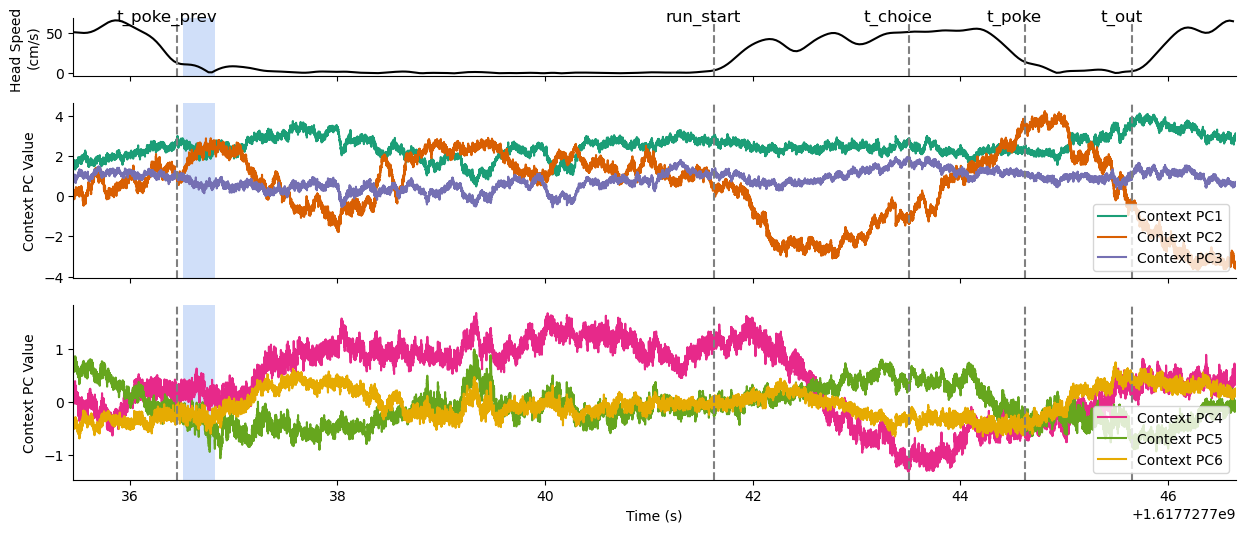

In [37]:
if nwb_file_name == "wilbur20210406_.nwb":
    trial = 124
elif nwb_file_name == "wilbur20210404_.nwb":
    trial = 24

row = trial_df.iloc[trial]
t_start = row.t_poke_prev - 1
t_end = row.t_out + 1

fig, ax = plt.subplots(nrows=3, height_ratios=[1, 3, 3], figsize=(15, 6), sharex=True)
c_ax_1= ax[1]
c_ax_2 = ax[2]
speed_ax = ax[0]





# Speed
pos_st = np.digitize(t_start, pos_df.index.values)
pos_en = np.digitize(t_end, pos_df.index.values)
pos_df_plot = pos_df.iloc[pos_st:pos_en]
speed_ax.plot(pos_df_plot.index.values, pos_df_plot["head_speed"].values, color="black")
speed_ax.set_ylabel("Head Speed \n(cm/s)")

# Context
ind_st = np.digitize(t_start, analysis.t)
ind_en = np.digitize(t_end, analysis.t)
ind_plot = slice(ind_st, ind_en)
for i in range(0, 3):
    c_ax_1.plot(analysis.t[ind_plot], analysis.c_pca[ind_plot, i], label=f"Context PC{i+1}",
                color = plt.cm.Dark2(i/8))
for i in range(3,6):
    c_ax_2.plot(analysis.t[ind_plot], analysis.c_pca[ind_plot, i], label=f"Context PC{i+1}",
                color = plt.cm.Dark2(i/8))
for a in [c_ax_1, c_ax_2]:
    a.set_ylabel("Context PC Value")

# Mark Events
times_to_mark = ["t_poke_prev", "run_start", "t_choice", "t_poke", "t_out"]
ylim = ax[0].get_ylim()
for time in times_to_mark:
    ax[0].text(row[time]-.1, 1 * ylim[1], time, fontsize=12, ha='center', va='center')
    if not np.isnan(row[time]):
        for i_a, a in enumerate(ax):
            a.axvline(row[time], color="grey", linestyle="--")
            a.spines[["top", "right"]].set_visible(False)
            a.set_xlim(t_start, t_end)

pump_in_window = [interval for interval in all_pump_intervals if interval[0] >= t_start and interval[1] <= t_end]
for a in ax:
    ylim = a.get_ylim()
    for interval in pump_in_window:
        a.fill_betweenx(ylim, interval[0], interval[1], facecolor="cornflowerblue", alpha=0.3)
    a.set_ylim(ylim)

for a in [c_ax_1, c_ax_2]:
    a.legend(loc="lower right")

ax[-1].set_xlabel("Time (s)")

plt.rcParams["svg.fonttype"] = "none"
fig.savefig(fig_dir / f"example_trial_{trial}.svg",)


# Task Progression

## Make task progression feature

In [5]:
t_run_norm = np.ones_like(analysis.t_interp) * -1
for st, en in trial_df[["run_start", "t_poke"]].values:
    if np.isnan(st) or np.isnan(en):
        continue
    ind_st = np.searchsorted(analysis.t_interp, st)
    ind_en = np.searchsorted(analysis.t_interp, en)
    t_run_norm[ind_st:ind_en] = np.linspace(0, 1, ind_en - ind_st)
_df = trial_df[trial_df.n_pre_switch != 0]
feature_intervals = _df[["run_start", "t_poke"]].values
feature = t_run_norm
t_feature = analysis.t_interp

## Bin task progression (per trial)

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
trial_binned_task_progression = []
progression_bins = np.linspace(0,1,150)
intervals = trial_df[["run_start", "t_poke"]].values#[:40]

from multiprocessing import Pool
from tqdm import tqdm

def process_interval(interval):
    if np.isnan(interval).any():
        return [[] for _ in range(len(progression_bins) - 1)]
    st = np.searchsorted(analysis.t_interp, interval[0])
    en = np.searchsorted(analysis.t_interp[st:], interval[1]) + st
    if en <= st:
        return [[] for _ in range(len(progression_bins) - 1)]
    results, bins = analysis.bin_context_by_feature(
        feature = t_run_norm[st:en],
        feature_times = analysis.t_interp[st:en],
        bins = progression_bins,
        pca=True,
        valid_intervals = [interval]
    )
    return results

trial_binned_task_progression = []
with Pool(processes=32) as pool:  # Adjust the number of processes as needed
    trial_binned_task_progression = list(tqdm(pool.imap(process_interval, intervals), total=len(intervals)))



# from tqdm import tqdm
# for interval in tqdm(intervals):
#     if np.isnan(interval).any():
#         trial_binned_task_progression.append([[] for _ in range(len(progression_bins) - 1)])
#         continue
#     st = np.searchsorted(analysis.t_interp, interval[0])
#     en = np.searchsorted(analysis.t_interp[st:], interval[1]) + st
#     results, bins = analysis.bin_context_by_feature(
#         feature = t_run_norm[st:en],
#         feature_times = analysis.t_interp[st:en],
#         bins = progression_bins,
#         pca=True,
#         valid_intervals = [interval]
#     )
#     trial_binned_task_progression.append(results)

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 1416/1416 [01:25<00:00, 16.51it/s]


In [8]:
lens = []
for interval in intervals:
    st = np.searchsorted(analysis.t_interp, interval[0])
    en = np.searchsorted(analysis.t_interp[st:], interval[1]) + st
    lens.append(en - st)

np.nanmin(lens)

np.int64(0)

### All  non-switch trials

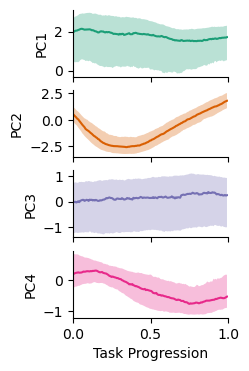

In [9]:
_df = trial_df.copy()
_df = _df[_df.n_pre_switch > 0]
ind = _df.index

results = [[] for _ in range(len(progression_bins)-1)]
for i in ind:
    for j in range(len(progression_bins) - 1):
        if len(trial_binned_task_progression[i]) == 0:
            continue
        if len(trial_binned_task_progression[i][j]) == 0:
            continue
        results[j].append(trial_binned_task_progression[i][j])

results = [np.concatenate(vals, axis=0) for vals in results]

fig, ax = plt.subplots(nrows=4, sharex=True, figsize=(2,4))
mid = np.array([np.nanmedian(vals,axis=0) for vals in results])
lo = np.array([np.nanpercentile(vals, 25,axis=0) for vals in results])
hi = np.array([np.nanpercentile(vals, 75,axis=0  ) for vals in results])

for i, a in enumerate(ax):
    color = plt.cm.Dark2(i/8)
    a.plot(progression_bins[:-1], mid[:,i], color=color)
    a.fill_between(progression_bins[:-1], lo[:,i], hi[:,i], facecolor=color, alpha=0.3)
    a.set_ylabel(f"PC{i+1}")
    a.spines[["top", "right"]].set_visible(False)
ax[-1].set_xlabel("Task Progression")
ax[-1].set_xlim(0,1)

fig.savefig(fig_dir / f"task_progression_binned.svg",)

In [16]:
fig_dir

PosixPath('/home/sambray/Documents/c3po/Figures/Fig5/mpfc_task_progression/wilbur_20210406_mpfc_HYBRID')

In [ ]:
# _df = trial_df.copy()
# _df = _df[_df.n_pre_switch > 0]


# reward_list = [False, True]
# reward_name_list = ["unrewarded", "rewarded"]
# reward_colors = ["#1f77b4", "#ff7f0e"]

# n_plot = 20
# fig, ax = plt.subplots(nrows=n_plot, sharex=True, figsize=(2,n_plot))
# for reward, reward_name, color in zip(reward_list, reward_name_list, reward_colors):
#     _df_reward = _df[_df.prev_trial_reward == reward]

#     ind = _df_reward.index

#     results = [[] for _ in range(len(progression_bins)-1)]
#     for i in ind:
#         for j in range(len(progression_bins) - 1):
#             if len(trial_binned_task_progression[i]) == 0:
#                 continue
#             if len(trial_binned_task_progression[i][j]) == 0:
#                 continue
#             results[j].append(trial_binned_task_progression[i][j])

#     results = [np.concatenate(vals, axis=0) for vals in results]


#     mid = np.array([np.nanmedian(vals,axis=0) for vals in results])
#     lo = np.array([np.nanpercentile(vals, 25,axis=0) for vals in results])
#     hi = np.array([np.nanpercentile(vals, 75,axis=0  ) for vals in results])

#     for i, a in enumerate(ax):
#         # color = plt.cm.Dark2(i/8)
#         a.plot(progression_bins[:-1], mid[:,i], color=color, label=reward_name)
#         a.fill_between(progression_bins[:-1], lo[:,i], hi[:,i], facecolor=color, alpha=0.3)
#         a.set_ylabel(f"PC{i+1}")
#         a.spines[["top", "right"]].set_visible(False)
#     ax[-1].set_xlabel("Task Progression")
#     ax[-1].set_xlim(0,1)
# ax[0].legend(loc="upper right", frameon=False, fontsize=8)
# # fig.savefig(fig_dir / f"task_progression_binned.svg",)

## Spikes by progression

In [ ]:
target_c = mid[:,pc_inds]
target_angles = np.arctan2(target_c[:,1], target_c[:,0])

In [21]:
analysis.params['params']['embedding']['encoder']['sorted_encoder']['encoder_matrix']

Array([[ 0.17216893, -0.00146184, -0.03656312, ...,  0.0550008 ,
         0.11789172,  0.210482  ],
       [-0.01422431, -0.196722  ,  0.16182461, ..., -0.12429757,
        -0.0864742 ,  0.14374006],
       [-0.042415  ,  0.12897366, -0.04547785, ..., -0.22184885,
         0.01782331, -0.19467396],
       ...,
       [ 0.13732201, -0.12704533, -0.01169971, ...,  0.07683069,
         0.1202354 ,  0.19609116],
       [ 0.1986444 , -0.02836964, -0.01220041, ...,  0.00289251,
         0.2133111 ,  0.11214469],
       [-0.0942044 , -0.13442941,  0.08697441, ..., -0.08765589,
        -0.00570391,  0.00561056]], dtype=float32)

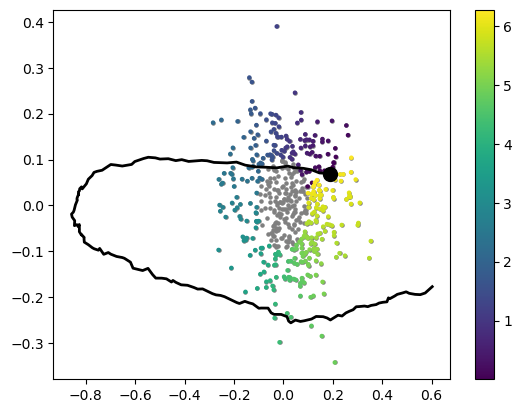

In [27]:
pc_inds = (3,1)
pc_inds = np.array([1,3])

thresh = .1
# pc_inds = np.array([6,5])

# z_neuron = [zz for zz in sorted_df.z_neuron.values]

z_neuron = analysis.params['params']['embedding']['encoder']['sorted_encoder']['encoder_matrix']
z_neuron = z_neuron @ analysis.pca.components_.T


z_neuron = np.array(z_neuron)[:, pc_inds]
z_mag = np.linalg.norm(z_neuron, axis=1)
z_angle = np.arctan2(z_neuron[:, 1], z_neuron[:, 0])

rot = np.pi / 4
rot= - np.pi * (3/2)
rot += np.pi * (3/8)
z_angle = (z_angle + np.pi+rot)%(2*np.pi)


target_c = mid[:,pc_inds].copy()
target_angles = np.arctan2(target_c[:,1], target_c[:,0])


ind_sig = np.where(z_mag > thresh)[0]
ind_sorted = ind_sig[np.argsort(z_angle[ind_sig])]

plt.scatter(z_neuron[:, 0], z_neuron[:, 1], color="grey", s=5, alpha = 1)
plt.scatter(z_neuron[ind_sig, 0], z_neuron[ind_sig, 1], c=z_angle[ind_sig], cmap="viridis", s=5)

plt.colorbar()
plt.plot(target_c[:, 0]/3, target_c[:, 1]/3, color="black", linewidth=2)
plt.scatter(target_c[0, 0]/3, target_c[0, 1]/3, color="black", s=100)

In [ ]:
# plt.plot(z_angle)
target_angles[0], target_angles[-1]

(np.float64(3.1307125926023307), np.float64(-2.7042543619503157))

In [ ]:

# pc_inds = np.array([1,3])
# # pc_inds = np.array([3,1])

# z_angle = []
# z_var = []
# z_vals = []
# for z in tqdm(sorted_df.z.values):
#     z = z @ analysis.pca.components_[pc_inds].T
#     z_vals.append(z.mean(axis=0))
#     z_angle_i = np.arctan2(z[1], z[0])
#     # mean_angle = np.arctan2(np.mean(np.sin(z_angle)), np.mean(np.cos(z_angle)))
#     # r_me
#     z_angle.append(circmean(z_angle_i))
#     z_var.append(circvar(z_angle_i))

# z_angle = np.array(z_angle)
# z_var = np.array(z_var)
# z_vals = np.array(z_vals)
# # z_neuron = [zz for zz in sorted_df.z_neuron.values]
# # z_neuron = np.array(z_neuron)[:, pc_inds]
# # z_mag = np.linalg.norm(z_neuron, axis=1)
# # z_angle = np.arctan2(z_neuron[:, 1], z_neuron[:, 0])

# # ind_sig = np.where(z_mag > .05)[0]
# # ind_sorted = ind_sig[np.argsort(z_angle[ind_sig])]

# # plt.scatter(z_neuron[:, 0], z_neuron[:, 1], color="grey", s=5, alpha = 1)
# # plt.scatter(z_neuron[ind_sig, 0], z_neuron[ind_sig, 1], c=z_angle[ind_sig], cmap="viridis", s=5)

# # plt.colorbar()

In [ ]:
# # plt.scatter(z_vals[:, 0], z_vals[:, 1], c=z_angle, s=5, alpha = 1,cmap="hsv")
# plt.scatter(z_vals[:, 0], z_vals[:, 1], c=z_var, s=5, alpha = 1,cmap="plasma")
# # plt.scatter(z_vals[ind_sig, 0], z_vals[ind_sig, 1], c=z_angle[ind_sig], cmap="hsv", s=5)

In [15]:
spike_times = spikes.copy()

100%|██████████| 329/329 [00:06<00:00, 54.74it/s]


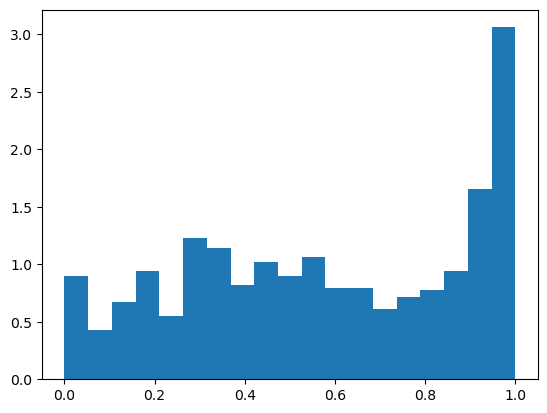

In [28]:
from c3po.analysis.intervals import interval_list_contains, interval_list_contains_ind

_df = trial_df.copy()
# _df = _df[_df.n_pre_switch > 0]
active_intervals = _df[["run_start", "t_poke"]].values

min_spikes = 300
progression_bins = np.linspace(0,1,20)

ind = interval_list_contains_ind(active_intervals, analysis.t_interp)
vals = t_run_norm[ind]
normalized_counts, _ = np.histogram(vals, bins=progression_bins, )

rates = []
kept_ids = []
for neuron_id in tqdm(ind_sorted):
    # neuron = sorted_df.iloc[neuron_id]
    # spike_times[i]
    # spikes = neuron.spike_times

    spikes = spike_times[neuron_id]
    spikes = interval_list_contains(active_intervals, spikes)
    if len(spikes) < min_spikes:
        continue

    ind_spikes =np.digitize(spikes, analysis.t_interp)
    prog_spikes = t_run_norm[ind_spikes]
    neuron_counts = np.histogram(prog_spikes, bins=progression_bins, density=True)[0]
    neuron_counts = neuron_counts / normalized_counts
    neuron_counts = neuron_counts / np.mean(neuron_counts)
    rates.append(neuron_counts)
    kept_ids.append(neuron_id)
plt.hist(prog_spikes, bins=progression_bins, density=True)
rates = np.array(rates)
# rates = rates / np.mean(rates, axis=1, keepdims=True)

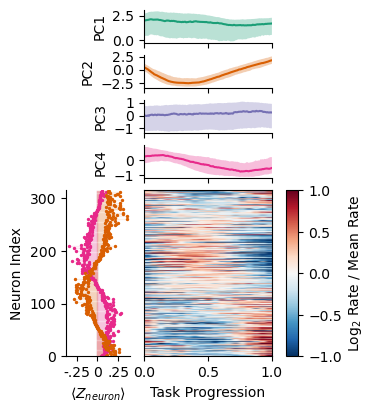

In [33]:
r = 1

n_pcs=4
fig, ax = plt.subplots(ncols=3,nrows=n_pcs+1, width_ratios=[1.5,3,.3],height_ratios=[1] * n_pcs +[5], figsize=(3,4.5), sharey=False,
                       sharex="col")
heat_ax = ax[-1, 1]
val_ax = ax[-1, 0]
pc_ax = ax[:-1, 1]
cmap_ax = ax[-1, 2]

for a in ax[:-1, 0]:
    a.axis("off")
for a in ax[:-1, 2]:
    a.axis("off")

for i in range(n_pcs):
    pc_prog_bins = np.linspace(0,1, mid.shape[0])
    pc_ax[i].plot(pc_prog_bins, mid[:,i], color=plt.cm.Dark2(i/8))
    pc_ax[i].fill_between(pc_prog_bins, lo[:,i], hi[:,i], facecolor=plt.cm.Dark2(i/8), alpha=0.3)
    pc_ax[i].set_ylabel(f"PC{i+1}")
    pc_ax[i].spines[["top", "right"]].set_visible(False)

cm = heat_ax.imshow(np.log2(rates), cmap = "RdBu_r", clim = (-r,r), extent = (progression_bins[0], progression_bins[-1], 0, rates.shape[0]),
            aspect="auto")
heat_ax.set_xlabel("Task Progression")
heat_ax.set_yticks([])
heat_ax.set_ylim(0, rates.shape[0])

cbar = plt.colorbar(cm, cax=cmap_ax)
cbar.set_label("Log$_2$ Rate / Mean Rate")

for i in range(rates.shape[0]):
    for i_pc, pc in enumerate(pc_inds):
        val_ax.scatter([z_neuron[kept_ids[i],i_pc]],[i] , color=plt.cm.Dark2(pc/8), s=2,
                       zorder = -i_pc)
        val_ax.plot([0, z_neuron[kept_ids[i],i_pc]],[i,i] , color=plt.cm.Dark2(pc/8),
                    linewidth=1,
                    alpha = .1,
                    zorder = -4)
val_ax.set_xlabel("$\langle Z_{neuron}\\rangle$")
val_ax.set_ylabel("Neuron Index")
val_ax.set_ylim(0, rates.shape[0])
val_ax.spines[["top", "right"]].set_visible(False)
val_ax.set_xticks([-0.25, 0, 0.25])
val_ax.set_xticklabels(["-.25", "0", ".25"])

fig.savefig(fig_dir / f"task_progression_binned_neuron_rates.svg",)


## Progression x  Leaf A update

In [ ]:
def bootstrap_confidence_interval(data, num_bootstrap_samples=1000, confidence_level=0.95):
    """
    Compute the bootstrap confidence interval for the mean of the data.

    Parameters:
        data (array-like): The input data.
        num_bootstrap_samples (int): Number of bootstrap samples to generate.
        confidence_level (float): The desired confidence level (between 0 and 1).
    Returns:
        tuple: Lower and upper bounds of the confidence interval.
    """
    means = []
    n = len(data)

    inds = np.arange(n)
    for _ in range(num_bootstrap_samples):
        # Generate a bootstrap sample by sampling with replacement
        bootstrap_sample = np.random.choice(inds, size=n, replace=True)
        means.append(np.mean(data[bootstrap_sample],axis=0))

    # Calculate the lower and upper percentiles for the confidence interval
    lower_percentile = (1 - confidence_level) / 2 * 100
    upper_percentile = (1 + confidence_level) / 2 * 100
    lower_bound = np.nanpercentile(means, lower_percentile,axis=0)
    upper_bound = np.nanpercentile(means, upper_percentile,axis=0)

    return lower_bound, upper_bound

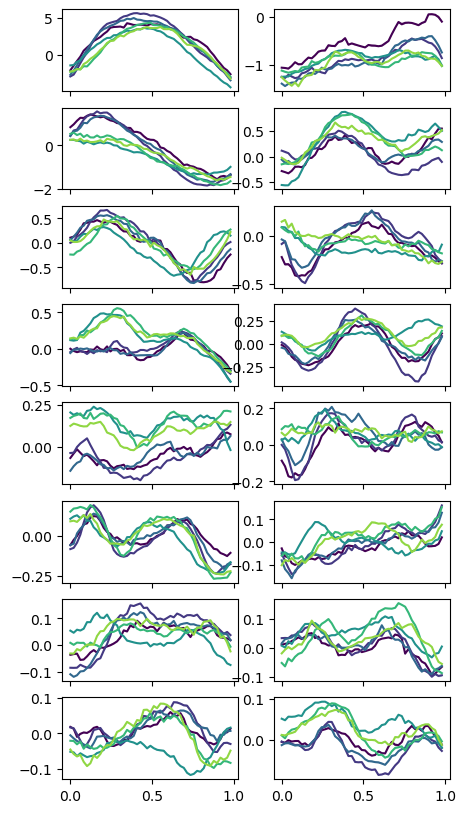

In [ ]:
_df = trial_df.copy()
_df = _df[_df.n_pre_switch > 1]
_df = _df[_df.epoch ==2]

feature = "Q_leaf_A_update"
feature_bins = np.nanpercentile(_df[feature].values, np.linspace(10,90,7))

fig, ax = plt.subplots(nrows=8,ncols=2, sharex=True, figsize=(5,10))
ax = ax.flatten()
for i_feature in range(len(feature_bins) - 1):
    ind = (_df[feature] >= feature_bins[i_feature]) & (_df[feature] < feature_bins[i_feature+1])
    ind = _df[ind].index
    results = [[] for _ in range(len(progression_bins)-1)]
    for i in ind:
        for j in range(len(progression_bins) - 1):
            if len(trial_binned_task_progression[i]) == 0:
                continue
            if len(trial_binned_task_progression[i][j]) == 0:
                continue
            results[j].append(trial_binned_task_progression[i][j])

    results = [np.concatenate(vals, axis=0) for vals in results]

    mid = np.array([np.nanmean(vals,axis=0) for vals in results])
    lo = []
    hi = []
    for vals in results:
        if len(vals) == 0:
            lo.append(np.nan)
            hi.append(np.nan)
        else:
            lower, upper = bootstrap_confidence_interval(vals, num_bootstrap_samples=10, confidence_level=0.95)
            lo.append(lower)
            hi.append(upper)
    lo = np.array(lo)
    hi = np.array(hi)
    # lo = np.array([np.nanpercentile(vals, 25,axis=0) for vals in results])
    # hi = np.array([np.nanpercentile(vals, 75,axis=0  ) for vals in results])

    color = plt.cm.viridis(i_feature/(len(feature_bins) - 1))
    for i, a in enumerate(ax):
        # color = plt.cm.Dark2(i/8)
        a.plot(progression_bins[:-1], mid[:,i], color=color, label=f"{feature_bins[i_feature]:.2f} - {feature_bins[i_feature+1]:.2f}")
        a.fill_between(progression_bins[:-1], lo[:,i], hi[:,i], facecolor=color, alpha=0.3)
        # a.set_ylabel(f"PC{i+1}")

# ax[0].legend(loc="lower right", fontsize=8, title=feature)

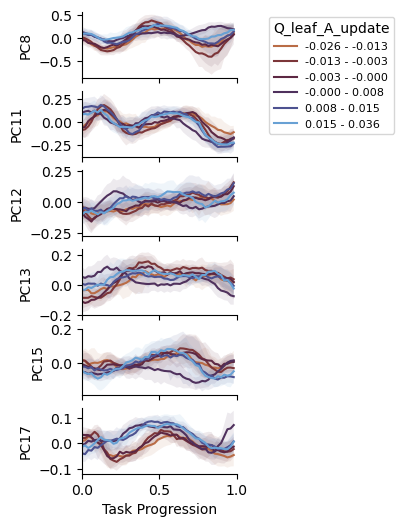

In [ ]:
pc_to_plot = [7,10,11,12,14,16]
_df = trial_df.copy()
_df = _df[_df.n_pre_switch > 1]
_df = _df[_df.epoch ==2]

feature = "Q_leaf_A_update"
feature_bins = np.nanpercentile(_df[feature].values, np.linspace(10,90,7))
# feature_bins = np.linspace(-0.2,.2,5)

fig, ax = plt.subplots(nrows=len(pc_to_plot), sharex=True, figsize=(2,len(pc_to_plot)))
ax = ax.flatten()
for i_feature in range(len(feature_bins) - 1):
    ind = (_df[feature] >= feature_bins[i_feature]) & (_df[feature] < feature_bins[i_feature+1])
    ind = _df[ind].index
    if len(ind) == 0:
        continue
    results = [[] for _ in range(len(progression_bins)-1)]
    for i in ind:
        for j in range(len(progression_bins) - 1):
            if len(trial_binned_task_progression[i]) == 0:
                continue
            if len(trial_binned_task_progression[i][j]) == 0:
                continue
            results[j].append(trial_binned_task_progression[i][j])
    if all(len(vals) == 0 for vals in results):
        continue
    results = [np.concatenate(vals, axis=0) for vals in results]

    mid = np.array([np.nanmean(vals,axis=0) for vals in results])
    lo = []
    hi = []
    for vals in results:
        if len(vals) == 0:
            lo.append(np.nan)
            hi.append(np.nan)
        else:
            lower, upper = bootstrap_confidence_interval(vals, num_bootstrap_samples=10, confidence_level=0.95)
            lo.append(lower)
            hi.append(upper)
    lo = np.array(lo)
    hi = np.array(hi)
    lo = np.array([np.nanpercentile(vals, 25,axis=0) for vals in results])
    hi = np.array([np.nanpercentile(vals, 75,axis=0  ) for vals in results])

    # color = plt.cm.viridis(i_feature/(len(feature_bins) - 1))
    c_val = np.mean([feature_bins[i_feature], feature_bins[i_feature+1]])
    c_max = np.nanmax(np.abs(feature_bins))
    c_val = c_val/c_max
    c_val = (c_val + 1)/2
    color = plt.cm.managua(c_val)

    for i, (a, pc) in enumerate(zip(ax, pc_to_plot,)):
        # color = plt.cm.Dark2(i/8)
        a.plot(progression_bins[:-1], mid[:,pc], color=color, label=f"{feature_bins[i_feature]:.3f} - {feature_bins[i_feature+1]:.3f}")
        a.fill_between(progression_bins[:-1], lo[:,pc], hi[:,pc], facecolor=color, alpha=0.1)
        # a.set_ylabel(f"PC{i+1}")

for i,a in enumerate(ax):
    a.set_ylabel(f"PC{pc_to_plot[i]+1}")
    a.spines[["top", "right"]].set_visible(False)
plt.xlim(0,1)
ax[0].legend(loc="upper right", fontsize=8, title=feature, bbox_to_anchor=(2.05, 1))
ax[-1].set_xlabel("Task Progression")

fig.savefig(fig_dir / f"task_progression_binned_{feature}.svg",)

# Progression x Q_leaf_A

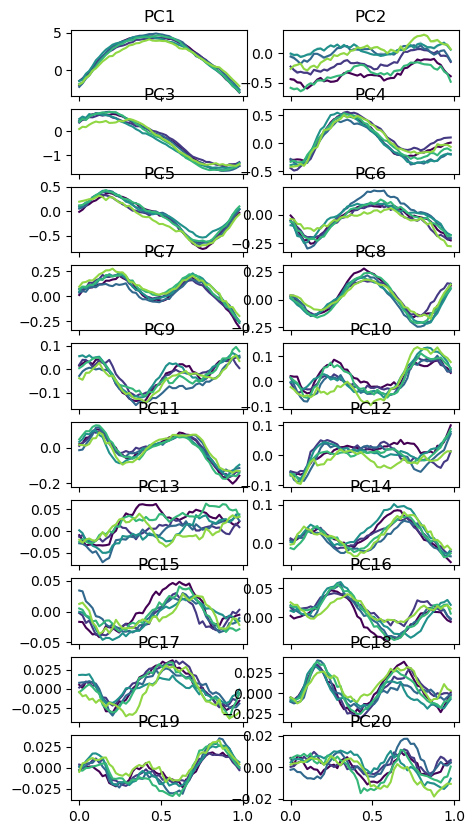

In [ ]:
_df = trial_df.copy()
_df = _df[_df.n_pre_switch > 0]
_df = _df[_df.epoch <=4]

feature = "Q_leaf_B"
feature = "Q_stem_trial"
feature_bins = np.nanpercentile(_df[feature].values, np.linspace(10,90,7))
# feature_bins = np.linspace(-0.2,.2,5)

fig, ax = plt.subplots(nrows=10,ncols=2, sharex=True, figsize=(5,10))
ax = ax.flatten()
for i_feature in range(len(feature_bins) - 1):
    ind = (_df[feature] >= feature_bins[i_feature]) & (_df[feature] < feature_bins[i_feature+1])
    ind = _df[ind].index
    if len(ind) == 0:
        continue
    results = [[] for _ in range(len(progression_bins)-1)]
    for i in ind:
        for j in range(len(progression_bins) - 1):
            if len(trial_binned_task_progression[i]) == 0:
                continue
            if len(trial_binned_task_progression[i][j]) == 0:
                continue
            results[j].append(trial_binned_task_progression[i][j])

    results = [np.concatenate(vals, axis=0) for vals in results]

    mid = np.array([np.nanmean(vals,axis=0) for vals in results])
    lo = []
    hi = []
    for vals in results:
        if len(vals) == 0:
            lo.append(np.nan)
            hi.append(np.nan)
        else:
            lower, upper = bootstrap_confidence_interval(vals, num_bootstrap_samples=10, confidence_level=0.95)
            lo.append(lower)
            hi.append(upper)
    lo = np.array(lo)
    hi = np.array(hi)
    # lo = np.array([np.nanpercentile(vals, 25,axis=0) for vals in results])
    # hi = np.array([np.nanpercentile(vals, 75,axis=0  ) for vals in results])

    color = plt.cm.viridis(i_feature/(len(feature_bins) - 1))
    for i, a in enumerate(ax):
        # color = plt.cm.Dark2(i/8)
        a.plot(progression_bins[:-1], mid[:,i], color=color, label=f"{feature_bins[i_feature]:.2f} - {feature_bins[i_feature+1]:.2f}")
        a.fill_between(progression_bins[:-1], lo[:,i], hi[:,i], facecolor=color, alpha=0.3)
        # a.set_ylabel(f"PC{i+1}")
        a.set_title(f"PC{i+1}")
# ax[0].legend(loc="lower right", fontsize=8, title=feature)

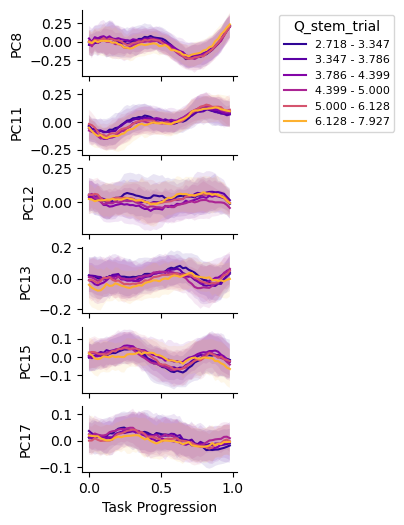

In [ ]:
pc_to_plot = [7,10,11,12,14,16,]
_df = trial_df.copy()
_df = _df[_df.n_pre_switch > 1]

feature = "Q_stem_trial"
feature_bins = np.nanpercentile(_df[feature].values, np.linspace(10,90,7))
# feature_bins = np.linspace(-0.2,.2,5)

fig, ax = plt.subplots(nrows=len(pc_to_plot), sharex=True, figsize=(2,len(pc_to_plot)))
ax = ax.flatten()
for i_feature in range(len(feature_bins) - 1):
    ind = (_df[feature] >= feature_bins[i_feature]) & (_df[feature] < feature_bins[i_feature+1])
    ind = _df[ind].index
    if len(ind) == 0:
        continue
    results = [[] for _ in range(len(progression_bins)-1)]
    for i in ind:
        for j in range(len(progression_bins) - 1):
            if len(trial_binned_task_progression[i]) == 0:
                continue
            if len(trial_binned_task_progression[i][j]) == 0:
                continue
            results[j].append(trial_binned_task_progression[i][j])
    if all(len(vals) == 0 for vals in results):
        continue
    results = [np.concatenate(vals, axis=0) for vals in results]

    mid = np.array([np.nanmean(vals,axis=0) for vals in results])
    lo = []
    hi = []
    for vals in results:
        if len(vals) == 0:
            lo.append(np.nan)
            hi.append(np.nan)
        else:
            lower, upper = bootstrap_confidence_interval(vals, num_bootstrap_samples=10, confidence_level=0.95)
            lo.append(lower)
            hi.append(upper)
    lo = np.array(lo)
    hi = np.array(hi)
    lo = np.array([np.nanpercentile(vals, 25,axis=0) for vals in results])
    hi = np.array([np.nanpercentile(vals, 75,axis=0  ) for vals in results])

    # color = plt.cm.viridis(i_feature/(len(feature_bins) - 1))
    c_val = np.mean([feature_bins[i_feature], feature_bins[i_feature+1]])
    color = c_val
    c_max = np.nanmax(feature_bins)
    c_min = np.nanmin(feature_bins)
    color = (c_val - c_min) / (c_max - c_min)  # Normalize to [0, 1]
    color = plt.cm.plasma(color)

    # c_
    # c_val = c_val/c_max
    # c_val = (c_val + 1)/2
    # color = plt.cm.managua(c_val)

    for i, (a, pc) in enumerate(zip(ax, pc_to_plot,)):
        # color = plt.cm.Dark2(i/8)
        a.plot(progression_bins[:-1], mid[:,pc], color=color, label=f"{feature_bins[i_feature]:.3f} - {feature_bins[i_feature+1]:.3f}")
        a.fill_between(progression_bins[:-1], lo[:,pc], hi[:,pc], facecolor=color, alpha=0.1)
        # a.set_ylabel(f"PC{i+1}")

for i,a in enumerate(ax):
    a.set_ylabel(f"PC{pc_to_plot[i]+1}")
    a.spines[["top", "right"]].set_visible(False)
ax[0].legend(loc="upper right", fontsize=8, title=feature, bbox_to_anchor=(2.05, 1))
ax[-1].set_xlabel("Task Progression")

fig.savefig(fig_dir / f"task_progression_binned_{feature}.svg",)

# Multi feature

In [ ]:
list(trial_df.keys())

['nwb_file_name',
 'epoch',
 'trial_number_by_epoch',
 'leaf',
 'stem',
 'reward',
 'contingency',
 'date',
 'session',
 'rewscaled',
 'stemchoice',
 'leafchoice',
 'daynum',
 'daysessionnum',
 'stemswitch',
 'n_post_switch',
 'n_pre_switch',
 'cont_combo',
 'contingency_base',
 'cont_base_combo',
 'sub',
 'betadist_α1',
 'betadist_α2',
 'betadist_α3',
 'betadist_α4',
 'betadist_α5',
 'betadist_α6',
 'betadist_β1',
 'betadist_β2',
 'betadist_β3',
 'betadist_β4',
 'betadist_β5',
 'betadist_β6',
 'betadist_var1',
 'betadist_var2',
 'betadist_var3',
 'betadist_var4',
 'betadist_var5',
 'betadist_var6',
 'Q1',
 'Q2',
 'Q3',
 'Q4',
 'Q5',
 'Q6',
 'Qdep1',
 'Qdep2',
 'Qdep3',
 'Qdep4',
 'Qdep5',
 'Qdep6',
 'Qstem1',
 'Qstem2',
 'Qstem3',
 'Qstem1_nobias',
 'Qstem2_nobias',
 'Qstem3_nobias',
 'Qstem1_pre_update_post_bias',
 'Qstem2_pre_update_post_bias',
 'Qstem3_pre_update_post_bias',
 'Qleaf1',
 'Qleaf2',
 'stem_stay_p',
 'stem_turn_alone_p',
 'stem_go_turn_p',
 'stem_1_p',
 'stem_2_p',
 's

Processing feature set 1/4: Q_leaf_A_update
Processing feature set 2/4: Q_stem_trial
Processing feature set 3/4: Q_leaf_A
Processing feature set 4/4: Q_leaf_B


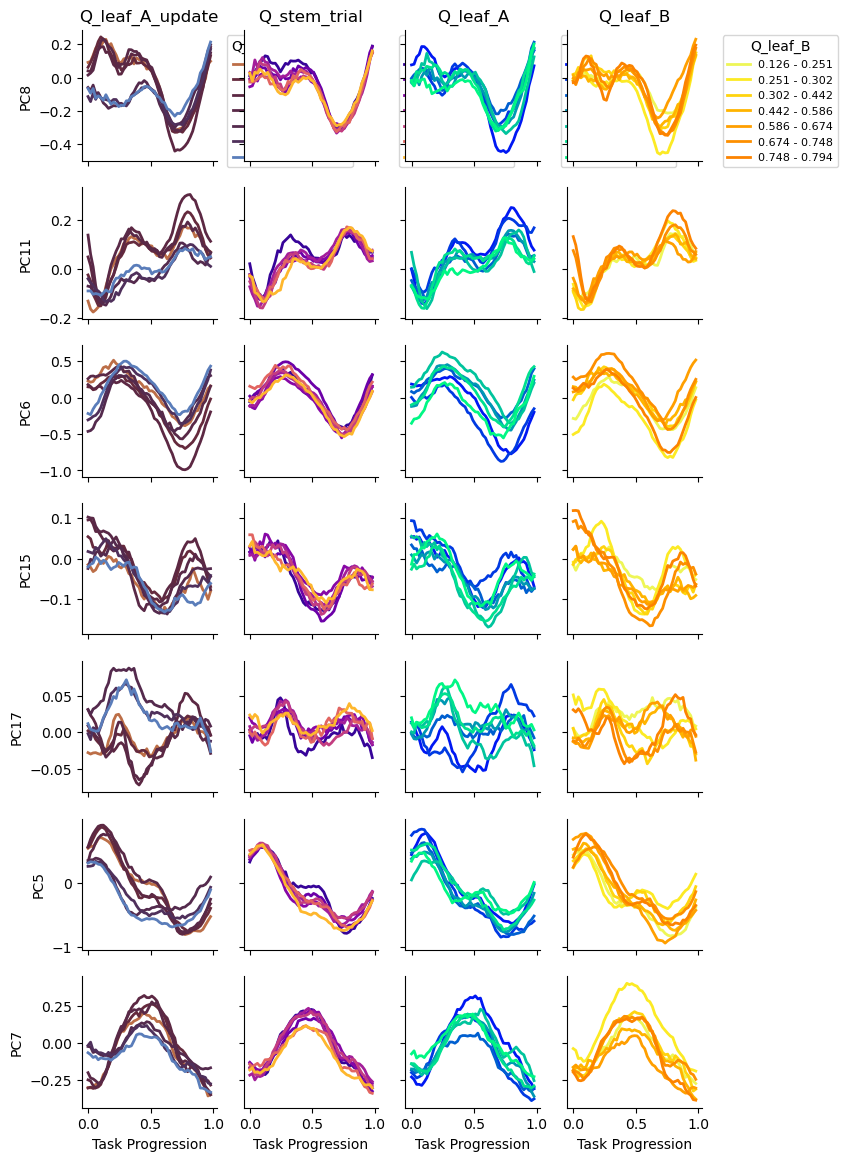

In [ ]:
pc_to_plot = [
    7,10, #only update
    # 11,12, #
    5,14,16, # update and leaf A
    4,6, # update +~stem coding
]
_df = trial_df.copy()
_df = _df[_df.n_pre_switch > 0]
_df = _df[_df.epoch <= 4]

feature_sets = []
percentiles = np.linspace(1,99,8)

feature_sets.append(dict(
    feature = "Q_leaf_A_update",
    feature_bins = np.nanpercentile(_df["Q_leaf_A_update"].values, percentiles),
    color_method = "diverge"
))


feature_sets.append(dict(
    feature = "Q_stem_trial",
    feature_bins = np.nanpercentile(_df["Q_stem_trial"].values, percentiles),
    color_method = plt.cm.plasma
))

feature_sets.append(dict(
    feature = "Q_leaf_A",
    feature_bins = np.nanpercentile(_df["Q_leaf_A"].values, percentiles),
    color_method = plt.cm.winter
))

feature_sets.append(dict(
    feature = "Q_leaf_B",
    feature_bins = np.nanpercentile(_df["Q_leaf_B"].values, percentiles),
    color_method = plt.cm.Wistia
))



fig, ax_list = plt.subplots(nrows=len(pc_to_plot),ncols=len(feature_sets),
                            sharex=True,sharey="row",
                            figsize=(2*len(feature_sets),2*len(pc_to_plot)))
if len(feature_sets) == 1:
    ax_list = ax_list[:, np.newaxis]  # Add a new axis to make it 2D
# feature_bins = np.linspace(-0.2,.2,5)

for i_feature_set, feature_set in enumerate(feature_sets):
    print(f"Processing feature set {i_feature_set+1}/{len(feature_sets)}: {feature_set['feature']}")
    feature = feature_set["feature"]
    feature_bins = feature_set["feature_bins"]
    color_method = feature_set["color_method"]
    ax = ax_list[:, i_feature_set]

    for i_feature in range(len(feature_bins) - 1):
        ind = (_df[feature] >= feature_bins[i_feature]) & (_df[feature] < feature_bins[i_feature+1])
        ind = _df[ind].index
        if len(ind) == 0:
            continue
        results = [[] for _ in range(len(progression_bins)-1)]
        for i in ind:
            for j in range(len(progression_bins) - 1):
                if len(trial_binned_task_progression[i]) == 0:
                    continue
                if len(trial_binned_task_progression[i][j]) == 0:
                    continue
                results[j].append(trial_binned_task_progression[i][j])
        if all(len(vals) == 0 for vals in results):
            continue
        results = [np.concatenate(vals, axis=0) for vals in results]

        mid = np.array([np.nanmean(vals,axis=0) for vals in results])
        lo = []
        hi = []
        for vals in results:
            if len(vals) == 0:
                lo.append(np.nan)
                hi.append(np.nan)
            else:
                lower, upper = bootstrap_confidence_interval(vals, num_bootstrap_samples=300, confidence_level=0.99)
                lo.append(lower)
                hi.append(upper)
        lo = np.array(lo)
        hi = np.array(hi)
        # lo = np.array([np.nanpercentile(vals, 25,axis=0) for vals in results])
        # hi = np.array([np.nanpercentile(vals, 75,axis=0  ) for vals in results])


        if color_method == "diverge":
            c_val = np.mean([feature_bins[i_feature], feature_bins[i_feature+1]])
            c_max = np.nanmax(np.abs(feature_bins))
            c_val = c_val/c_max
            c_val = (c_val + 1)/2
            color = plt.cm.managua(c_val)
        else:
            c_val = np.mean([feature_bins[i_feature], feature_bins[i_feature+1]])
            color = c_val
            c_max = np.nanmax(feature_bins)
            c_min = np.nanmin(feature_bins)
            color = (c_val - c_min) / (c_max - c_min)  # Normalize to [0, 1]
            color = color_method(color)

        # c_
        # c_val = c_val/c_max
        # c_val = (c_val + 1)/2
        # color = plt.cm.managua(c_val)

        for i, (a, pc) in enumerate(zip(ax, pc_to_plot,)):
            # color = plt.cm.Dark2(i/8)
            a.plot(progression_bins[:-1], mid[:,pc],lw=2,
                   color=color, label=f"{feature_bins[i_feature]:.3f} - {feature_bins[i_feature+1]:.3f}")
            a.fill_between(progression_bins[:-1], lo[:,pc], hi[:,pc], facecolor=color, alpha=0.1)
            # a.set_ylabel(f"PC{i+1}")

        for i,a in enumerate(ax):
            a.spines[["top", "right"]].set_visible(False)
        ax[0].legend(loc="upper right", fontsize=8, title=feature, bbox_to_anchor=(2.05, 1))
        ax[-1].set_xlabel("Task Progression")
        ax[0].set_title(feature_set['feature'])

for i,a in enumerate(ax_list[:,0]):
    a.set_ylabel(f"PC{pc_to_plot[i]+1}")

fig.savefig(fig_dir / f"task_progression_binned_multi_feature.svg",)

In [ ]:
ax_list.shape, ax.shape

((6, 2), (6,))

# Progression x Q_leaf_B

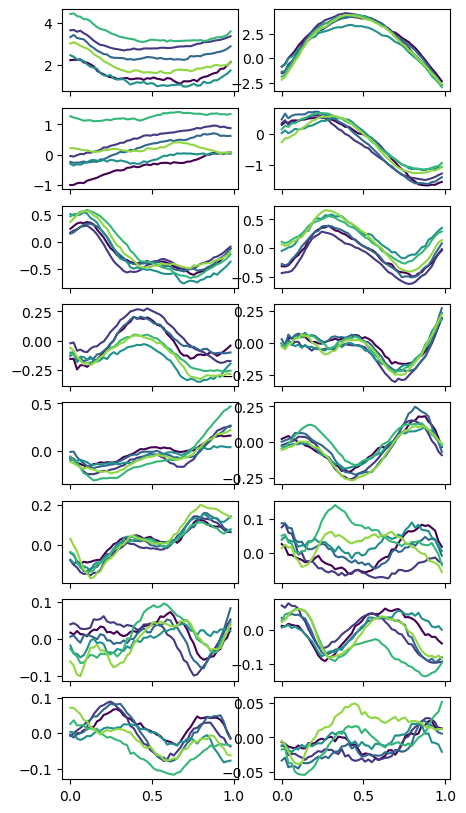

In [ ]:
_df = trial_df.copy()
_df = _df[_df.n_pre_switch > 1]
# _df = _df[_df.n_pre_switch == 0]

feature = "Q_leaf_B"
feature_bins = np.nanpercentile(_df[feature].values, np.linspace(10,90,7))

fig, ax = plt.subplots(nrows=8,ncols=2, sharex=True, figsize=(5,10))
ax = ax.flatten()
for i_feature in range(len(feature_bins) - 1):
    ind = (_df[feature] >= feature_bins[i_feature]) & (_df[feature] < feature_bins[i_feature+1])
    ind = _df[ind].index
    results = [[] for _ in range(len(progression_bins)-1)]
    for i in ind:
        for j in range(len(progression_bins) - 1):
            if len(trial_binned_task_progression[i]) == 0:
                continue
            if len(trial_binned_task_progression[i][j]) == 0:
                continue
            results[j].append(trial_binned_task_progression[i][j])

    results = [np.concatenate(vals, axis=0) for vals in results]

    mid = np.array([np.nanmean(vals,axis=0) for vals in results])
    lo = []
    hi = []
    for vals in results:
        if len(vals) == 0:
            lo.append(np.nan)
            hi.append(np.nan)
        else:
            lower, upper = bootstrap_confidence_interval(vals, num_bootstrap_samples=10, confidence_level=0.95)
            lo.append(lower)
            hi.append(upper)
    lo = np.array(lo)
    hi = np.array(hi)
    # lo = np.array([np.nanpercentile(vals, 25,axis=0) for vals in results])
    # hi = np.array([np.nanpercentile(vals, 75,axis=0  ) for vals in results])

    color = plt.cm.viridis(i_feature/(len(feature_bins) - 1))
    for i, a in enumerate(ax):
        # color = plt.cm.Dark2(i/8)
        a.plot(progression_bins[:-1], mid[:,i], color=color, label=f"{feature_bins[i_feature]:.2f} - {feature_bins[i_feature+1]:.2f}")
        a.fill_between(progression_bins[:-1], lo[:,i], hi[:,i], facecolor=color, alpha=0.3)
        # a.set_ylabel(f"PC{i+1}")

# ax[0].legend(loc="lower right", fontsize=8, title=feature)

Text(0.5, 0, 'Task Progression')

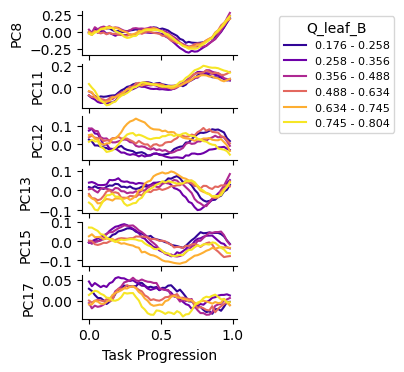

In [ ]:
pc_to_plot = [7,10,11,12,14,16]
_df = trial_df.copy()
_df = _df[_df.n_pre_switch > 1]
# _df = _df[_df.n_pre_switch == 0]

feature = "Q_leaf_B"
feature_bins = np.nanpercentile(_df[feature].values, np.linspace(10,90,7))
# feature_bins = np.linspace(-0.2,.2,5)

fig, ax = plt.subplots(nrows=len(pc_to_plot), sharex=True, figsize=(2,4))
ax = ax.flatten()
for i_feature in range(len(feature_bins) - 1):
    ind = (_df[feature] >= feature_bins[i_feature]) & (_df[feature] < feature_bins[i_feature+1])
    ind = _df[ind].index
    if len(ind) == 0:
        continue
    results = [[] for _ in range(len(progression_bins)-1)]
    for i in ind:
        for j in range(len(progression_bins) - 1):
            if len(trial_binned_task_progression[i]) == 0:
                continue
            if len(trial_binned_task_progression[i][j]) == 0:
                continue
            results[j].append(trial_binned_task_progression[i][j])
    if all(len(vals) == 0 for vals in results):
        continue
    results = [np.concatenate(vals, axis=0) for vals in results]

    mid = np.array([np.nanmean(vals,axis=0) for vals in results])
    lo = []
    hi = []
    for vals in results:
        if len(vals) == 0:
            lo.append(np.nan)
            hi.append(np.nan)
        else:
            lower, upper = bootstrap_confidence_interval(vals, num_bootstrap_samples=10, confidence_level=0.95)
            lo.append(lower)
            hi.append(upper)
    lo = np.array(lo)
    hi = np.array(hi)
    # lo = np.array([np.nanpercentile(vals, 25,axis=0) for vals in results])
    # hi = np.array([np.nanpercentile(vals, 75,axis=0  ) for vals in results])

    # color = plt.cm.viridis(i_feature/(len(feature_bins) - 1))
    c_val = np.mean([feature_bins[i_feature], feature_bins[i_feature+1]])
    color = c_val
    c_max = np.nanmax(feature_bins)
    c_min = np.nanmin(feature_bins)
    color = (c_val - c_min) / (c_max - c_min)  # Normalize to [0, 1]
    color = plt.cm.plasma(color)

    # c_
    # c_val = c_val/c_max
    # c_val = (c_val + 1)/2
    # color = plt.cm.managua(c_val)

    for i, (a, pc) in enumerate(zip(ax, pc_to_plot,)):
        # color = plt.cm.Dark2(i/8)
        a.plot(progression_bins[:-1], mid[:,pc], color=color, label=f"{feature_bins[i_feature]:.3f} - {feature_bins[i_feature+1]:.3f}")
        a.fill_between(progression_bins[:-1], lo[:,pc], hi[:,pc], facecolor=color, alpha=0.3)
        # a.set_ylabel(f"PC{i+1}")

for i,a in enumerate(ax):
    a.set_ylabel(f"PC{pc_to_plot[i]+1}")
    a.spines[["top", "right"]].set_visible(False)
ax[0].legend(loc="upper right", fontsize=8, title=feature, bbox_to_anchor=(2.05, 1))
ax[-1].set_xlabel("Task Progression")

# Progression x n_pre_switch

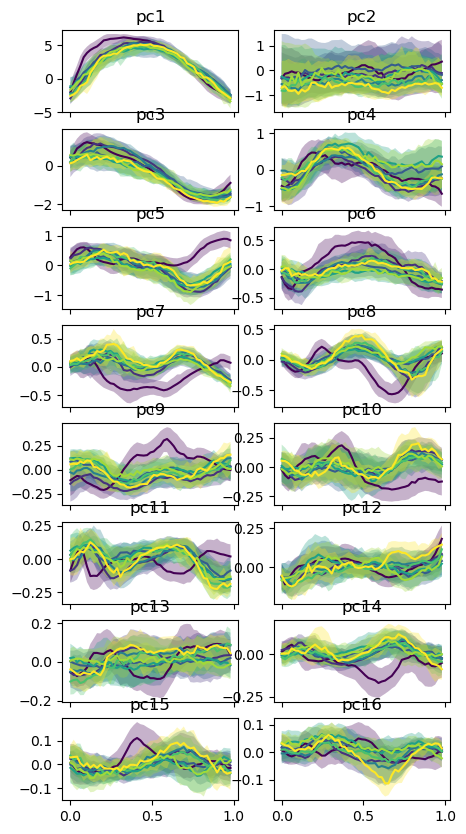

In [ ]:
_df = trial_df.copy()
# _df = _df[_df.n_pre_switch > 0]
# _df = _df[_df.prev_trial_reward == 0]
_df = _df[_df.epoch <= 6]

feature = "n_pre_switch"
feature_vals = np.arange(0,8)
# feature_vals = np.array([0,2,4,6])

fig, ax = plt.subplots(nrows=8,ncols=2, sharex=True, figsize=(5,10))
ax = ax.flatten()
mean_responses =[]
for i_feature in range(len(feature_vals)):

    ind = (_df[feature] == feature_vals[i_feature])
    ind = _df[ind].index
    results = [[] for _ in range(len(progression_bins)-1)]
    for i in ind:
        for j in range(len(progression_bins) - 1):
            if len(trial_binned_task_progression[i]) == 0:
                continue
            if len(trial_binned_task_progression[i][j]) == 0:
                continue
            results[j].append(trial_binned_task_progression[i][j])

    results = [np.concatenate(vals, axis=0) for vals in results]

    mid = np.array([np.nanmedian(vals,axis=0) for vals in results])
    mean_responses.append(mid)
    lo = []
    hi = []
    # for vals in results:
    #     if len(vals) == 0:
    #         lo.append(np.nan)
    #         hi.append(np.nan)
    #     else:
    #         lower, upper = bootstrap_confidence_interval(vals, num_bootstrap_samples=10, confidence_level=0.95)
    #         lo.append(lower)
    #         hi.append(upper)
    # lo = np.array(lo)
    # hi = np.array(hi)
    lo = np.array([np.nanpercentile(vals, 25,axis=0) for vals in results])
    hi = np.array([np.nanpercentile(vals, 75,axis=0  ) for vals in results])

    color = plt.cm.viridis(i_feature/(len(feature_vals) - 1))
    for i, a in enumerate(ax):
        # color = plt.cm.Dark2(i/8)
        a.set_title(f"pc{i+1}")
        a.plot(progression_bins[:-1], mid[:,i], color=color, label=f"{feature_vals[i_feature]:.2f}")
        a.fill_between(progression_bins[:-1], lo[:,i], hi[:,i], facecolor=color, alpha=0.3)
        # a.set_ylabel(f"PC{i+1}")

# ax[0].legend(loc="lower right", fontsize=8, title=feature)


Text(0.5, 0, 'PC5')

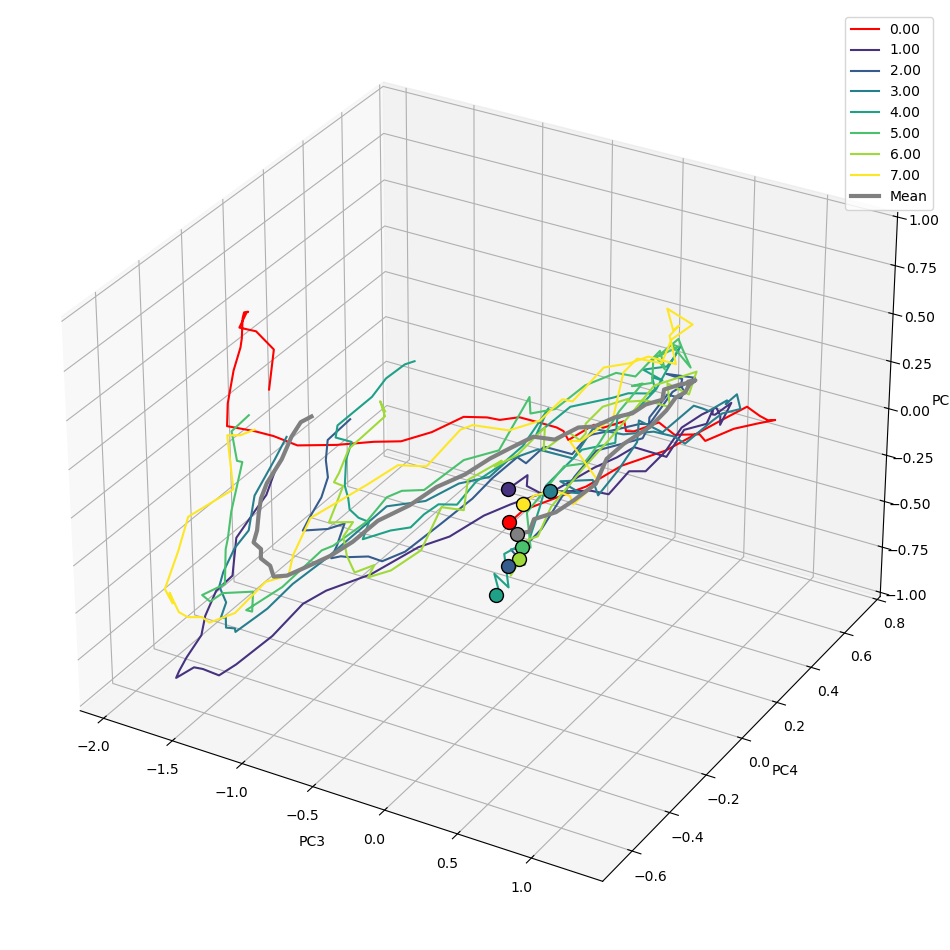

In [ ]:
fig = plt.figure(figsize=(12, 16))
ax = fig.add_subplot(111, projection='3d')

pcs = [2,3,4]
# pcs=[3,4,5]
# pcs=[2,4,12]
# pcs=[0,1,2]
all_mid = np.mean(mean_responses, axis=0)
for i_feature in range(len(feature_vals)):
    if feature_vals[i_feature] == 0:
        color="r"
    else:
        color = plt.cm.viridis(i_feature/(len(feature_vals) - 1))
    mid = mean_responses[i_feature]
    ax.plot(mid[:, pcs[0]], mid[:, pcs[1]], mid[:, pcs[2]], label=f"{feature_vals[i_feature]:.2f}", color=color)
    ax.scatter(mid[0, pcs[0]], mid[0, pcs[1]], mid[0, pcs[2]], color=color, s=100,edgecolor='k')

ax.plot(all_mid[:, pcs[0]], all_mid[:, pcs[1]], all_mid[:, pcs[2]], label="Mean", color="grey", lw=3)
ax.scatter(all_mid[0, pcs[0]], all_mid[0, pcs[1]], all_mid[0, pcs[2]], color="grey", s=100,edgecolor='k')
plt.legend()
ax.set_xlabel(f"PC{pcs[0]+1}")
ax.set_ylabel(f"PC{pcs[1]+1}")
ax.set_zlabel(f"PC{pcs[2]+1}")
# ax.azim = 20
# ax.elev = 20

# Alligned Responses

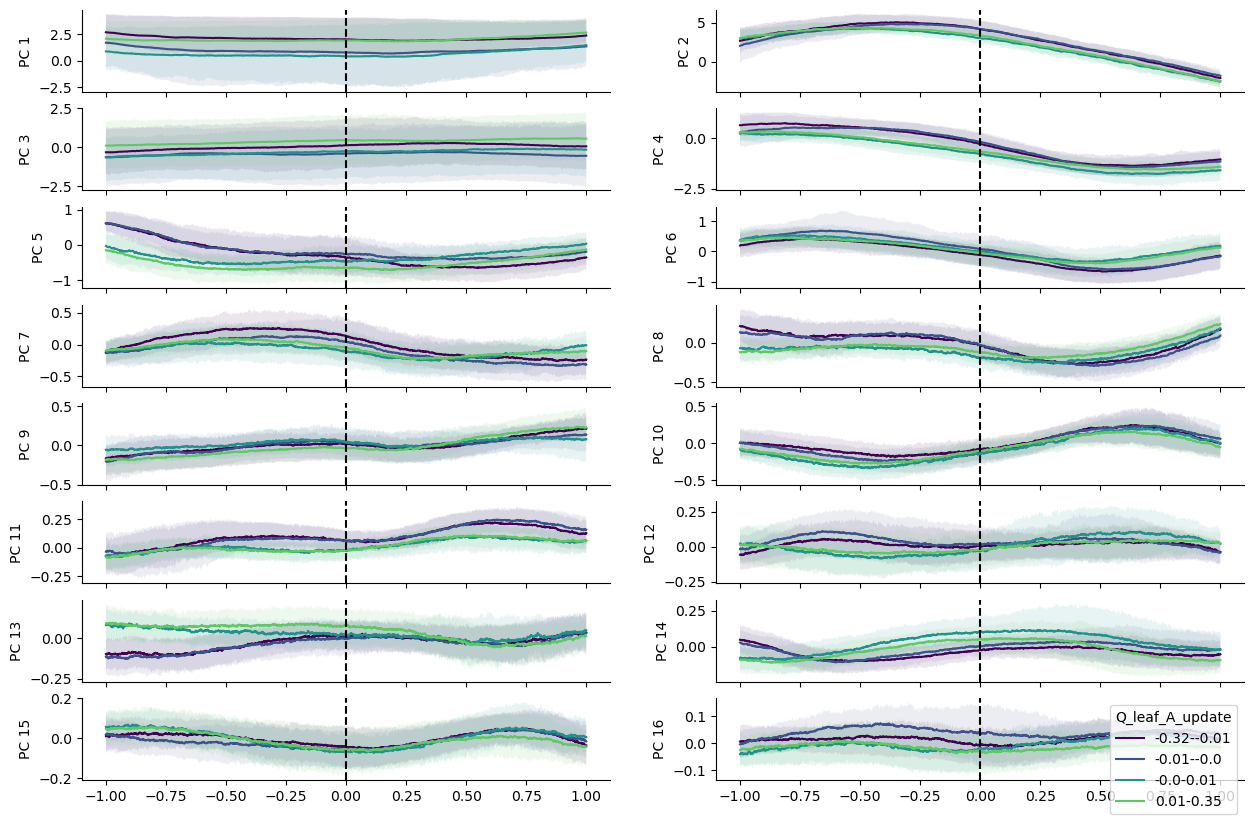

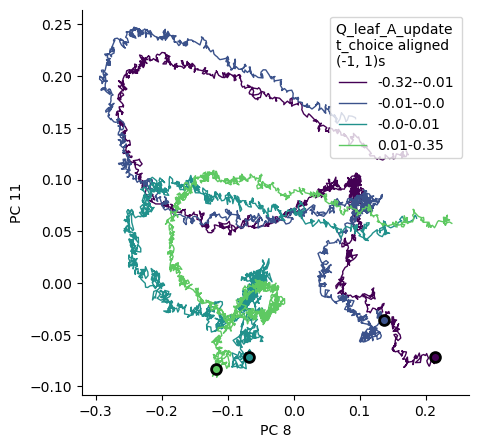

In [ ]:
two_dim = [5, 6]
two_dim = [0, 1]
two_dim = [1, 3]
two_dim = [7,10]

# -----------------------
mark_feature = "t_out"
window = (-1, 1)

mark_feature = "t_poke"
window = (-2.5, 1.5)

mark_feature = "run_start"
window = (-0, 2)

mark_feature = "t_choice"
window = (-1, 1)

# -----------------------
group_feature = "reward"
feature_bins = None

group_feature = "prev_trial_reward"
feature_bins = None

# group_feature = "stem_stay_p"
# feature_bins = np.linspace(0, 1, 11).round(2)
# feature_bins = np.percentile(
#     trial_df[group_feature].values, np.linspace(10, 90, 6)
# ).round(2)

# group_feature = "stem_choice_p"
# feature_bins = np.linspace(0, 1, 11).round(2)
# exclude_labels = ["start"]

# group_feature = "Q_trial"
# feature_bins = np.linspace(0, 0.8, 10).round(2)
# feature_bins = np.percentile(trial_df["Q_trial"].values, np.linspace(0, 100, 5)).round(
#     2
# )
group_feature = "Q_leaf_A_update"
feature_bins = np.linspace(0, 0.95, 10).round(2)
feature_bins = np.nanpercentile(trial_df[group_feature].values, np.linspace(0, 100, 5)).round(
    2
)

# group_feature = "Q_stem_trial"
# feature_bins = np.linspace(0, 0.8, 8).round(2)
# feature_bins = np.percentile(
#     trial_df["Q_stem_trial"].values, np.linspace(10, 90, 6)
# ).round(2)

# group_feature = "turns"
# feature_bins = None

# group_feature = "n_pre_switch"
# feature_bins = np.arange(5) + 0.1

# ------------------------
exclude_feature = "n_pre_switch"
exclude_feature_values = [0, -1]
exclude_labels = [None]

# exclude_feature = "reward"
# exclude_feature_values = [1]


# ------------------------
if exclude_feature is None:
    exclude_mask = np.zeros(len(trial_df), dtype=bool)
else:
    val = trial_df[exclude_feature].values
    exclude_mask = np.isin(val, exclude_feature_values)

if feature_bins is None:
    feature_values = trial_df[group_feature].values
    feature_labels = np.unique(feature_values).tolist()
    feature_labels = [
        label
        for label in feature_labels
        if (isinstance(label, str)) or not np.isnan(label)
    ]
    feature_labels = [label for label in feature_labels if label not in exclude_labels]
    category_inds = [feature_values == val for val in feature_labels]

else:
    feature_values = trial_df[group_feature].values
    category_inds = []
    feature_labels = []
    for lo, hi in zip(feature_bins[:-1], feature_bins[1:]):
        inds = (feature_values >= lo) & (feature_values <= hi)
        category_inds.append(inds)
        feature_labels.append(f"{lo}-{hi}")
# ---


fig, ax = plt.subplots(
    min(8, analysis.context_dim // 2), ncols=2, figsize=(15, 10), sharex=True
)
ax = ax.flatten()

fig_2d, ax_2d = plt.subplots(figsize=(5, 5))
for i_cat, (inds, label) in enumerate(zip(category_inds, feature_labels)):
    if inds.sum() == 0:
        continue
    marks = trial_df[mark_feature].values[np.logical_and(inds, ~exclude_mask)]

    response = analysis.alligned_response(marks, window, pca=True)
    mean_response = np.nanmean(response, axis=0)
    lo = np.nanpercentile(response, 25, axis=0)
    hi = np.nanpercentile(response, 75, axis=0)

    color = plt.cm.viridis(i_cat / len(category_inds))
    t_plot = np.linspace(
        window[0],
        window[1],
        mean_response.shape[0],
    )
    for i_dim, a in enumerate(ax):
        a.plot(t_plot, mean_response[:, i_dim], label=label, color=color)
        a.fill_between(t_plot, lo[:, i_dim], hi[:, i_dim], facecolor=color, alpha=0.1)
        a.set_ylabel(f"PC {i_dim+1}")

    ax_2d.plot(
        mean_response[:, two_dim[0]],
        mean_response[:, two_dim[1]],
        label=label,
        color=color,
        lw=1,
        zorder=-1,
    )
    ax_2d.scatter(
        mean_response[0, two_dim[0]],
        mean_response[0, two_dim[1]],
        color=color,
        s=50,
        edgecolors="k",
        lw=2,
    )

for a in ax:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.axvline(0, color="k", linestyle="--")
ax[-1].legend(title=f"{group_feature}")

ax_2d.spines[["top", "right"]].set_visible(False)
ax_2d.set_xlabel(f"PC {two_dim[0]+1}")
ax_2d.set_ylabel(f"PC {two_dim[1]+1}")
ax_2d.legend(
    title=f"{group_feature} \n{mark_feature} aligned \n({window[0]}, {window[1]})s"
)